`MNIST`Handwritten digits recognition `hands-on`


In [ ]:
# Import all the necessary Libraries
import numpy as np
import pandas as pd
import os
#--------------------------------------
import matplotlib.pyplot as plt
import seaborn as sn
import plotly.express as px
#--------------------------------------
import warnings
warnings.filterwarnings('ignore')
#--------------------------------------
import tensorflow as tf

# Load the `MNIST Handwritten Data`
- The `training`data consist of `60000 - 28x28 px` images of hand-written digits from `0` to `9`

- The `testing`data consist of `10000 - 28x28 px` images.



In [ ]:
mnist_data = tf.keras.datasets.mnist


In [ ]:
mnist_data

<module 'keras.datasets.mnist' from '/usr/local/lib/python3.12/dist-packages/keras/datasets/mnist/__init__.py'>

In [ ]:
(X_train , y_train),(X_test, y_test) = mnist_data.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
X_train.shape

(60000, 28, 28)

In [ ]:
print(f'The shape of the training dataset:{X_train.shape}\nThe shape of the training dataset:{X_test.shape}')

The shape of the training dataset:(60000, 28, 28)
The shape of the training dataset:(10000, 28, 28)


In [ ]:
print(f'The shape of the testing dataset:{y_test.shape}\nThe shape of the testing dataset:{y_test.shape}')

The shape of the testing dataset:(10000,)
The shape of the testing dataset:(10000,)


ploting some of the handwritten digits image from the `training dataset`

In [ ]:
fig = px.imshow(X_train[7],binary_string=True)
fig.show()

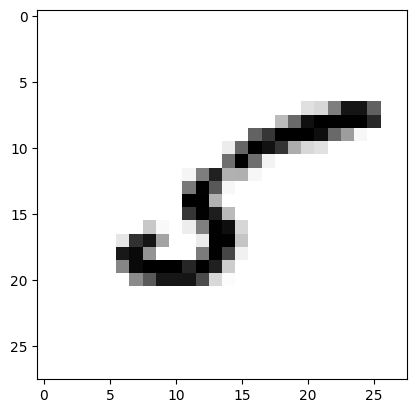

In [ ]:
plt.figsize = (5,5)
plt.imshow(X_train[11],cmap=plt.cm.binary)
plt.show()

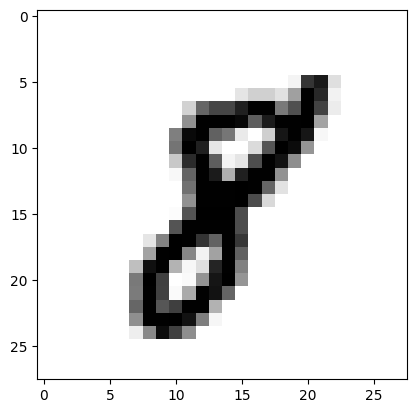

In [ ]:
plt.figsize = (5,5)
plt.imshow(X_train[17],cmap=plt.cm.binary)
plt.show()

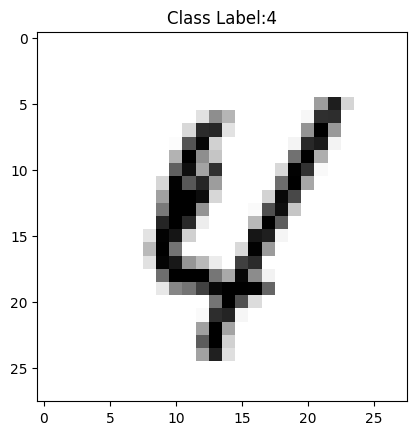

In [ ]:
plt.figsize = (5,5)
plt.imshow(X_train[700],cmap=plt.cm.binary)
plt.title(f'Class Label:{y_train[700]}')
plt.show()

ploting some of the handwritten digits image from the `testing dataset`

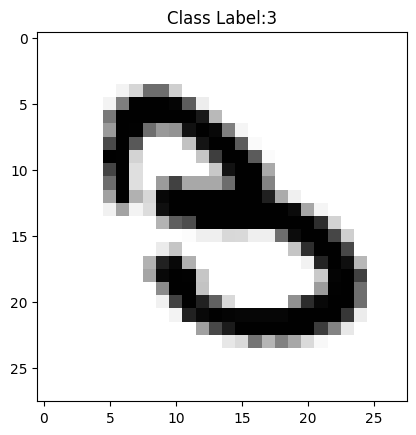

In [ ]:
plt.figsize = (5,5)
plt.imshow(X_test[18],cmap=plt.cm.binary)
plt.title(f'Class Label:{y_test[18]}')
plt.show()

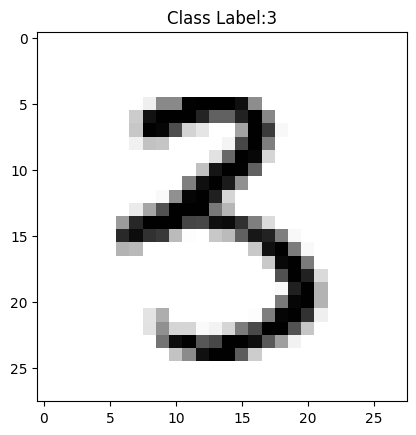

In [ ]:
plt.figsize = (5,5)
plt.imshow(X_test[5000],cmap=plt.cm.binary)
plt.title(f'Class Label:{y_test[5000]}')
plt.show()

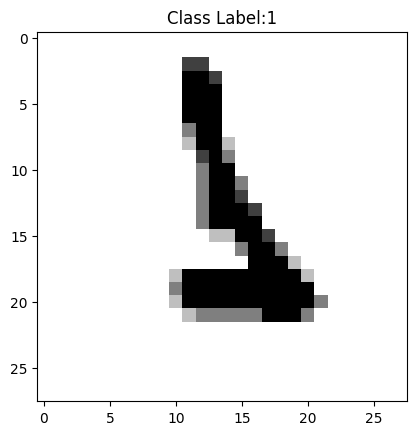

In [ ]:
plt.figsize = (5,5)
plt.imshow(X_test[956],cmap=plt.cm.binary)
plt.title(f'Class Label:{y_test[956]}')
plt.show()

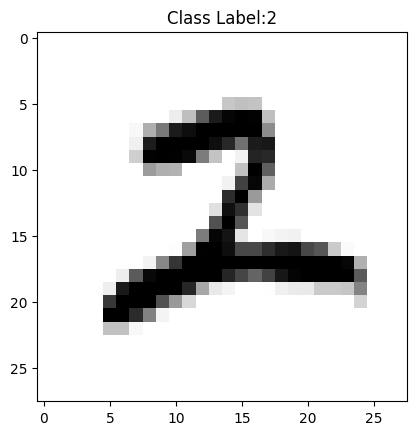

In [ ]:
plt.figsize = (5,5)
plt.imshow(X_test[7100],cmap=plt.cm.binary)
plt.title(f'Class Label:{y_test[7100]}')
plt.show()

**For `Training dataset`**

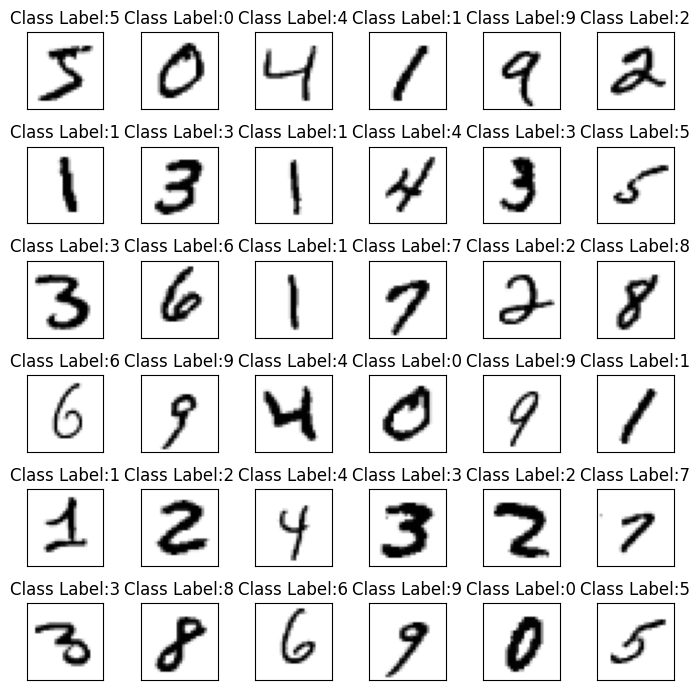

In [ ]:
n = 36
n_item = int(np.ceil(np.sqrt(n)))
plt.figure(figsize=(7,7))

for i in range(n):
  plt.subplot(n_item,n_item,i+1)
  plt.title(f'Class Label:{y_train[i]}')
  plt.imshow(X_train[i],cmap=plt.cm.binary)
  plt.xticks([])
  plt.yticks([])

plt.tight_layout()
plt.show()

**For `testing dataset`**

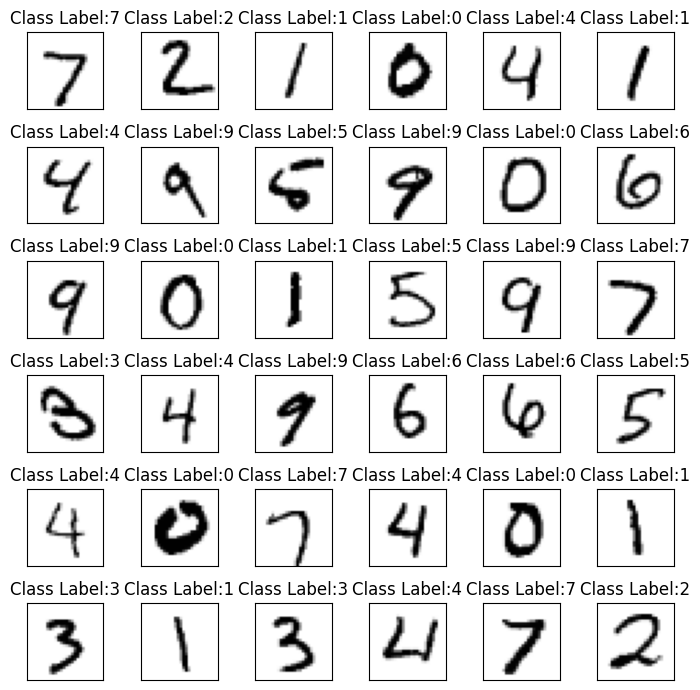

In [ ]:
n = 36
n_item = int(np.ceil(np.sqrt(n)))
plt.figure(figsize=(7,7))

for i in range(n):
  plt.subplot(n_item,n_item,i+1)
  plt.title(f'Class Label:{y_test[i]}')
  plt.imshow(X_test[i],cmap=plt.cm.binary)
  plt.xticks([])
  plt.yticks([])

plt.tight_layout()
plt.show()

# Let us build the `MNIST` model

In [ ]:
models = tf.keras.models.Sequential()

In [ ]:
models

<Sequential name=sequential_1, built=False>

Scale the X_train and X_test from `[0-255]` to `[0-1]`

In [ ]:
x_train_normalized = X_train/255
x_test_normalized = X_test/255

In [ ]:
x_train_normalized.min(),x_train_normalized.max()

(np.float64(0.0), np.float64(1.0))

In [ ]:
### Input Layer ######
models.add(tf.keras.layers.Flatten(input_shape =x_train_normalized.shape[1:]))
#-------------------------------------------------------------------------------
### Hidden Layer ####
models.add(tf.keras.layers.Dense(
    units = 128,
    activation = tf.keras.activations.relu))
#-------------------------------------------------------------------------------
### Second Hidden Layer having size 128
models.add(tf.keras.layers.Dense(
    units = 128,
    activation = tf.keras.activations.relu))
#-------------------------------------------------------------------------------
# output Layer
models.add(tf.keras.layers.Dense(
    units = 10,
    activation = tf.keras.activations.softmax))

In [ ]:
models.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,282 (462.04 KB)

 Trainable params: 118,282 (462.04 KB)

 Non-trainable params: 0 (0.00 B)

`Compilation` of the model

In [ ]:
adam_optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)

In [ ]:
models.compile(
    optimizer = adam_optimizer,
    loss = tf.keras.losses.SparseCategoricalCrossentropy,
    metrics = ['accuracy']
)

In [ ]:
###Train and validate the model

final = models.fit(x_train_normalized,y_train,epochs=30,validation_data=(x_test_normalized,y_test))

Epoch 1/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8821 - loss: 0.3908 - val_accuracy: 0.9332 - val_loss: 0.2426
Epoch 2/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9483 - loss: 0.1904 - val_accuracy: 0.9544 - val_loss: 0.1794
Epoch 3/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9573 - loss: 0.1576 - val_accuracy: 0.9528 - val_loss: 0.2026
Epoch 4/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9625 - loss: 0.1465 - val_accuracy: 0.9564 - val_loss: 0.1720
Epoch 5/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9641 - loss: 0.1356 - val_accuracy: 0.9637 - val_loss: 0.1375
Epoch 6/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9698 - loss: 0.1132 - val_accuracy: 0.9669 - val_loss: 0.1372
Epoch 7/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9708 - loss: 0.1152 - val_accuracy: 0.9657 - val_loss: 0.1505
Epoch 8/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9735 - loss: 0.

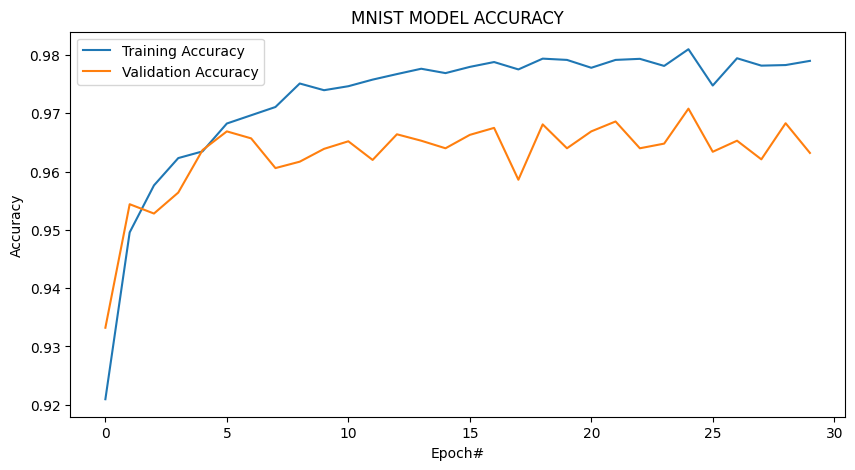

In [ ]:
plt.figure(figsize=(10,5))
sn.lineplot(final.history['accuracy'],label = 'Training Accuracy')
sn.lineplot(final.history['val_accuracy'], label = 'Validation Accuracy')
plt.xlabel('Epoch#')
plt.ylabel('Accuracy')
plt.title('MNIST MODEL ACCURACY')
plt.show()

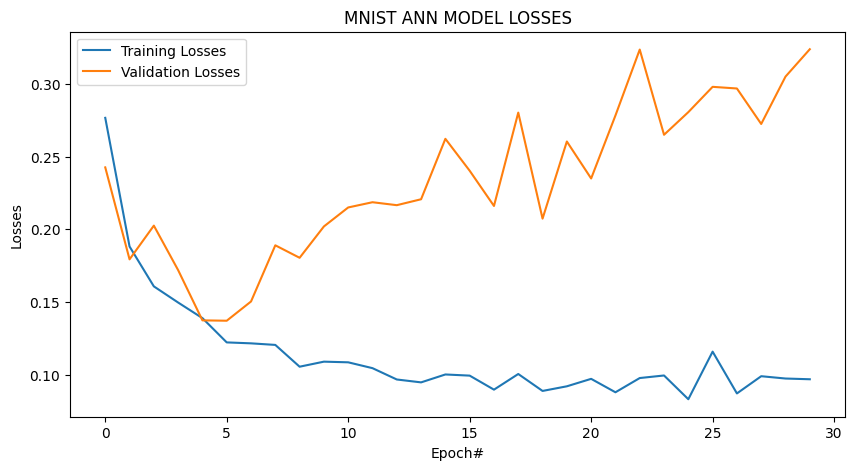

In [ ]:
plt.figure(figsize=(10,5))
sn.lineplot(final.history['loss'], label = 'Training Losses')
sn.lineplot(final.history['val_loss'], label = 'Validation Losses')
plt.xlabel('Epoch#')
plt.ylabel('Losses')
plt.title('MNIST ANN MODEL LOSSES')
plt.show()